# In this notebook we aim to answer the following questions:

### ✔ 1. Is there a country-level BPM preference?
### ✔ 2. Do faster/louder songs have higher popularity? Or popularity depends on the popularity of the artist?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

# Load the dataset with audio features and normalized popularity created in eu_normalized_popularity_top200.ipynb
df_charts= pd.read_csv("../data/eu_top200_with_custom_popularity.csv")
df_charts.info()

## 🔎  Univariate Analysis: data distribution of key audio features


#### We'll create a dataset by removing duplicate tracks from the top200 charts dataset loaded in the previous step, since the audio features are the same for track_id:

In [ ]:
df_charts.groupby('track_id').value_counts()

In [ ]:
columns_names = ['track_id','normalized_popularity','tempo','danceability','energy','loudness']
df_unique_tracks = df_charts[columns_names].drop_duplicates(subset=['track_id'])
df_unique_tracks.value_counts()

In [ ]:
# Analysis of the distribution of key audio features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_unique_tracks['tempo'].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Tempo Distribution')

df_unique_tracks['loudness'].hist(bins=50, ax=axes[0, 1])
axes[0, 1].set_title('Loudness Distribution')

df_unique_tracks['danceability'].hist(bins=50, ax=axes[1, 0])
axes[1, 0].set_title('Danceability Distribution')

df_unique_tracks['energy'].hist(bins=50, ax=axes[1, 1])
axes[1, 1].set_title('Energy Distribution')

plt.tight_layout()
plt.show()

## Summary

##### 🥁 Tempo
Clear multimodal distribution — peaks at ~95, ~120–130, ~150 BPM.
Most songs fall between ~90–150 BPM;    few very slow or very fast tracks.
We can see at least 3–4 distinct peaks:

| Peak | BPM | Likely genre |
|---|---|---|
| Peak 1 | ~80 BPM | Hip-hop, R&B |
| Peak 2 | ~100 BPM | Reggaeton, trap |
| Peak 3 | ~120–130 BPM | Pop, dance, EDM (dominant) |
| Peak 4 | ~150–160 BPM | Drum & bass, fast EDM, or half-time of ~75-80 BPM |

The **120–130 BPM peak is clearly dominant**, but the other modes are visible and meaningful.

##### 🥁 Loudness
Strong left skew; values clustered near the loud end (~-8 to -4 dB), peak ~-5 dB.
Few very quiet tracks; charts dominated by loud, highly compressed productions [loudness‑war effect](https://en.wikipedia.org/wiki/Loudness_war).
##### 🥁 Danceability
Approximately bell‑shaped, slightly left‑skewed; peak around 0.65–0.8.
Most chart tracks are fairly danceable; low danceability is rare.
##### 🥁 Energy
Left‑skewed with a broad plateau; peak around 0.6–0.8.
High‑energy tracks are common but distribution is wider than danceability (more variety).


## 🇪🇺 1. Country-level Tempo/BPM preference analysis in EU

####  Not-weighted distribution, analyze the tempo distribution based only on the presence of a track in the charts

In [ ]:
# Load the European regions mapping from CSV
eu_regions = pd.read_csv('../data/european_countries.csv')
region_map = dict(zip(eu_regions['country'], eu_regions['region']))

# Map each country (df_charts['country']) to its European macro-region
df_charts['eu_region'] = df_charts['country'].map(region_map)

palette = {
    'Northern Europe': '#2ecc71',
    'Western Europe': '#3498db',
    'Southern Europe': '#e74c3c',
    'Eastern Europe': '#f39c12',
}

plt.figure(figsize=(14, 6))
sns.kdeplot(data=df_charts, x='tempo', hue='eu_region',
            fill=True, alpha=0.15, palette=palette, linewidth=2, common_norm=False)
plt.xlabel('Tempo (BPM)')
plt.title('Tempo Distribution by European Region')
sns.move_legend(plt.gca(), loc='upper left', bbox_to_anchor=(1, 1), title='European Region')
plt.tight_layout()
plt.show()

## Summary

**Overall pattern**
- All regions share two main tempo peaks:
  - **~95–105 BPM** (mid-tempo, groove-oriented)
  - **~120–130 BPM** (dance / club standard)
- This indicates a strong, shared European tempo backbone.

**Regional characteristics**
- **Southern Europe**
  - Fastest overall tempo profile
  - Strong high-BPM tail (≈160–190+ BPM)
  - Emphasis on energetic, rhythm-forward tracks

- **Western Europe**
  - Most pronounced peak at **~125 BPM**
  - Highly standardized, club-oriented tempos
  - Moderate presence of very fast tracks

- **Northern Europe**
  - Most balanced distribution
  - Broad spread between **100–140 BPM**
  - Fewer extreme fast tempos

- **Eastern Europe**
  - Slightly faster than West/North on average
  - Strong presence around **130–150 BPM**
  - Less extreme high-BPM tail than Southern Europe


#### Streams-weighted tempo distribution

Weigh tempo by `streams` so each track contributes proportionally to how many times it was streamed.

In [ ]:

plt.figure(figsize=(14, 6))
for region in df_charts['eu_region'].unique():
    regional_df = df_charts.loc[df_charts['eu_region'] == region]
    # KDE weighted by streams for a cleaner per-region density
    sns.kdeplot(data=regional_df, x='tempo', weights=regional_df['streams'].values, bw_adjust=1.0,
                fill=False, alpha=0.9, linewidth=2, common_norm=False, label=region)

# global (all-region) streams-weighted KDE
sns.kdeplot(data=df_charts, x='tempo', weights=df_charts['streams'].values, bw_adjust=1.0,
            color='k', linestyle='--', fill=False, common_norm=False, label='All regions (streams-weighted)')

plt.xlabel('Tempo (BPM)')
plt.ylabel('Streams-weighted density')
plt.title('Streams-weighted Tempo Distribution by European Region (KDE)')
plt.legend(bbox_to_anchor=(1, 1), title='Region')
plt.tight_layout()
plt.show()

## Summary
### Streams-weighted vs Unweighted Tempo Distributions (General)

- **Unweighted distributions** reflect the diversity of produced music, showing a wide range of tempos.
- **Streams-weighted distributions** reflect listening behavior, where a smaller set of tempos dominates.
- Weighting by streams compresses tempo diversity, amplifying a few highly popular tempo ranges.
- **Extreme tempos** (very slow or very fast) remain present but account for relatively little overall listening.


## 🔗‍️ 2. Analyze correlation matrix of key audio features (identify relationship between pairs of variables)

In [ ]:
# Correlation matrix for audio features vs normalized_popularity
features = ['tempo', 'loudness', 'energy', 'danceability', 'normalized_popularity']
corr = df_unique_tracks[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Correlation: Audio Features vs Normalized Popularity')
plt.tight_layout()
plt.show()

## Summary
### Relationship Between Audio Features and Popularity

Pearson correlation analysis indicates **no meaningful linear relationship between tempo and normalized popularity**(r ≈ −0.02), suggesting that faster songs are not associated with higher popularity. 

Loudness shows a weak positive correlation with popularity (r ≈ 0.08); however, the magnitude of this association is small and unlikely to be practically significant. 

Overall, these results suggest that basic audio features such as tempo and loudness alone do not strongly explain variation in song popularity.


#### ➡️ Given the weak linear correlations, additional analyses are required to assess whether tempo and loudness influence popularity in more complex ways

In [ ]:
df_artists = pd.read_csv("../data/kaggle2/artists.csv")
df_artists.head()

In [ ]:
df_artists.info()

In [ ]:
df_artists.isna().sum()

In [ ]:
df_artists['followers'] = df_artists['followers'].fillna(0)
df_artists['name'] = df_artists['name'].fillna("Unknown Artist")

In [ ]:
df_artists = df_artists.drop_duplicates(subset=['id'])
df_artists = df_artists.rename(columns={"id": "artist_id"})

In [ ]:
df_tracks = pd.read_csv("../data/eu_top200_with_custom_popularity.csv")
df_tracks.head()

In [ ]:
merged_df = pd.merge(df_tracks,df_artists, left_on="id_main_artist",right_on="artist_id", how="left")
merged_df.columns

In [ ]:
merged_df.shape

In [ ]:
merged_df["artist_id"].isna().sum()

In [ ]:
10053 / 4520058 * 100

#### The merge between track and artist datasets resulted in only 0.22% unmatched records, therefore an inner join can be used to ensure clean artist-level analysis without introducing significant bias.

In [ ]:
inner_merged_df = pd.merge(df_tracks,df_artists, left_on="id_main_artist",right_on="artist_id", how="inner")
inner_merged_df.columns

In [67]:
df_artists = df_artists.dropna(subset=['artist_id'])
df_artists.to_csv("../data/artists_clean.csv", index=False)

In [ ]:
inner_merged_df.rename(columns={"normalized_popularity": "track_custom_popularity", "popularity_y": "artist_popularity"}, inplace=True)
columns_to_drop = ["rank", "chart", 'streams', "popularity_x", "artists","id_artists", "artist_id", "name"]
inner_merged_df.drop(columns=columns_to_drop, inplace=True)
inner_merged_df

##### ⚠️ The popularity column in the artists datasets is a global score (1-100), not region based, so if we want an Eu-focused analysis, we need to calculate the percentage of `followers` for each artist in Europe.

In [51]:
inner_merged_df['id_main_artist'].nunique()

4831

In [52]:
inner_merged_df['id_main_artist'].value_counts()[lambda x: x > 1]

id_main_artist
6eUKZXaKkcviH0Ku9w2n3V    103569
6qqNVTkY8uBg9cP3Jd7DAH     79517
246dkjvS1zLTtiykXe5h60     74599
6M2wZ9GZgrQXHCFfjv46we     59254
15UsOTVnJzReFVN1VCnxy4     57543
                           ...  
4KnCJu3hmsLrG3XTNs8Jw0         2
0EodhzA6yW1bIdD5B4tcmJ         2
3ayds6VIVBx3CU5NSNCDbq         2
2FjkZT851ez950cyPjeYid         2
7ChbI909duz2evHDqsYsSa         2
Name: count, Length: 4410, dtype: int64

In [53]:
total_followers = inner_merged_df['followers'].sum()

followers_by_artist = inner_merged_df.groupby('id_main_artist')['followers'].sum() / total_followers
# Scale to 0-100 using min-max normalization
normalized_followers = (followers_by_artist - followers_by_artist.min()) / (followers_by_artist.max() - followers_by_artist.min()) * 100
normalized_followers.name = "artist_custom_popularity"
normalized_followers.sort_values(ascending=False)

id_main_artist
6eUKZXaKkcviH0Ku9w2n3V    1.000000e+02
6qqNVTkY8uBg9cP3Jd7DAH    4.066786e+01
66CXWjxzNUsdJxJ2JdwvnR    3.146812e+01
246dkjvS1zLTtiykXe5h60    2.936598e+01
3TVXtAsR1Inumwj472S9r4    2.364631e+01
                              ...     
1pXQjCSdwuxicBATPszhf7    1.223748e-11
0w7y29nbgQSKh7WcT092gE    0.000000e+00
5FupCmv9gE6V6V8OHTWGSk    0.000000e+00
6blXIxXn98P6dGH6paK9a1    0.000000e+00
72drPmU37vqwm8fnaYANzN    0.000000e+00
Name: artist_custom_popularity, Length: 4831, dtype: float64

In [69]:
df_artists_with_custom_popularity = inner_merged_df.merge(normalized_followers, on="id_main_artist")
df_artists_with_custom_popularity.to_csv("../data/artists_with_custom_popularity.csv", index=False)

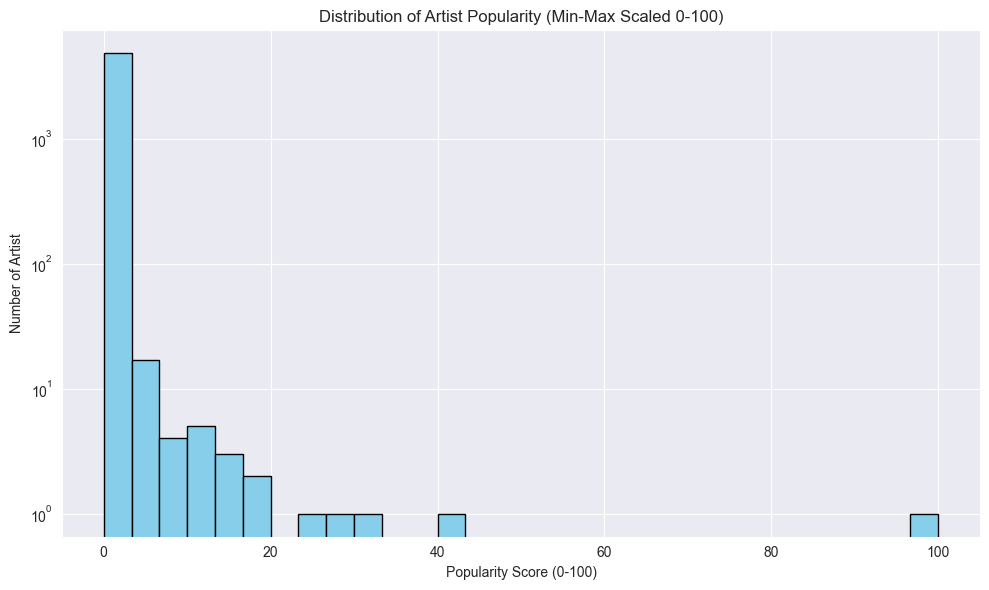

In [54]:
plt.figure(figsize=(10, 6))
plt.hist(normalized_followers, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Artist Popularity (Min-Max Scaled 0-100)')
plt.xlabel('Popularity Score (0-100)')
plt.yscale('log')
plt.ylabel('Number of Artist')
plt.tight_layout()
plt.show()

In [55]:
inner_merged_df_with_popularity = inner_merged_df.merge(normalized_followers, on="id_main_artist")
inner_merged_df_with_popularity.drop_duplicates(subset='id_main_artist')

,title,date,country,track_id,duration_ms,explicit,danceability,energy,key,loudness,...,valence,tempo,time_signature,main_artist,id_main_artist,track_custom_popularity,followers,genres,artist_popularity,artist_custom_popularity
0,Alone,2017-01-01,Austria,0JiVRyTJcJnmlwCZ854K4p,161200,0,0.676,0.929,10,-3.194,...,0.157,97.019,4,Alan Walker,7vk5e3vY1uw9plTHJAMwjN,8.164351,28026432.0,['electro house'],85,7.566667
1,Rockabye (feat. Sean Paul & Anne-Marie),2017-01-01,Austria,5knuzwU65gJK7IF5yJsuaW,251088,0,0.720,0.763,9,-4.068,...,0.742,101.965,4,Clean Bandit,6MDME20pz9RveH9rEXvrOM,23.522081,4293412.0,"['dance pop', 'edm', 'pop', 'pop dance', 'post...",81,1.296333
2,Bad Ideas,2017-01-01,Austria,76gwG061wqdatYhicO2hG4,166213,0,0.749,0.710,7,-6.630,...,0.678,120.005,4,Alle Farben,61ipISvUVa5LkJlKZnm3Oo,2.431793,294206.0,"['deep euro house', 'edm', 'german dance', 'po...",72,0.009051
3,Closer,2017-01-01,Austria,7BKLCZ1jbUBVqRi2FVlTVw,244960,0,0.748,0.524,8,-5.599,...,0.661,95.010,4,The Chainsmokers,69GGBxA162lTqCwzJG5jLp,11.683320,17734996.0,"['dance pop', 'edm', 'electropop', 'pop', 'pop...",85,6.541984
4,Call On Me - Ryan Riback Extended Remix,2017-01-01,Austria,78rIJddV4X0HkNAInEcYde,222041,0,0.670,0.838,0,-4.031,...,0.717,104.998,4,Starley,02A3cEvlLLCbIMVDrK2GHV,18.511417,132073.0,"['aussietronica', 'dance pop', 'pop dance', 't...",63,0.008944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4501583,U Can't Touch This,2017-12-31,Poland,1B75hgRqe7A4fwee3g3Wmu,257360,0,0.867,0.517,11,-13.222,...,0.866,133.148,4,MC Hammer,2rblp9fJo16ZPTcKDtlmKW,0.001187,405473.0,"['hip hop', 'hip house', 'new jack swing', 'rap']",62,0.000005
4503911,Werewolves of London - 2007 Remaster,2021-10-31,Ireland,6kotXaSQaGYxE62hVpdHWu,209467,0,0.750,0.620,7,-8.720,...,0.930,103.538,4,Warren Zevon,3mY9Ii0cL5SQxpOTAm8SHx,0.000594,266189.0,"['classic rock', 'country rock', 'folk', 'folk...",63,0.000003
4504964,Get Up (Rattle) - Radio Edit,2017-12-31,Sweden,1UKdrdB8kt9N8SQ4nJNRnd,156320,0,0.722,0.969,7,-5.511,...,0.670,125.872,4,Bingo Players,1pbHrVayIcVpHI9z97u4bK,0.006867,433580.0,"['big room', 'dance pop', 'edm', 'electro hous...",64,0.000005
4504986,Baby Baby - Lee Marrow Radio Mix,2017-12-31,Sweden,5Hr2Q8DMEn25u3tu2sqcpQ,226907,0,0.645,0.855,7,-9.298,...,0.579,133.026,4,Corona,26T6b8maqEVltcmE4kSDUl,0.005375,131750.0,"['bubblegum dance', 'diva house', 'eurodance',...",62,0.000002


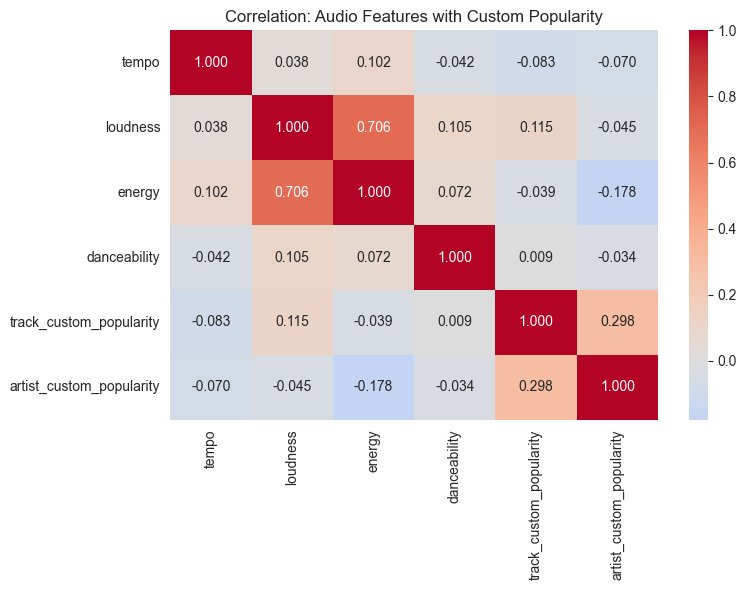

In [56]:
# Correlation matrix for audio features vs normalized_popularity
features = ['tempo', 'loudness', 'energy', 'danceability', 'track_custom_popularity','artist_custom_popularity']
corr = inner_merged_df_with_popularity[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Correlation: Audio Features with Custom Popularity')
plt.tight_layout()
plt.show()

#### Conclusion:

##### 👉 Audio features alone are poor predictors of track popularity (at least linearly), popularity is more artist-driven than feature-driven and is multi-factorial.

##### Let's analyze the joint effect of multiple predictors with a **Multiple linear regression**:

In [57]:
import statsmodels.api as sm

X = inner_merged_df_with_popularity[['tempo', 'loudness', 'artist_custom_popularity']]
X = sm.add_constant(X)

y = inner_merged_df_with_popularity['track_custom_popularity']

model = sm.OLS(y, X).fit()
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     track_custom_popularity   R-squared:                       0.110
Model:                                 OLS   Adj. R-squared:                  0.110
Method:                      Least Squares   F-statistic:                 1.858e+05
Date:                     Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                             19:37:09   Log-Likelihood:            -1.8080e+07
No. Observations:                  4510005   AIC:                         3.616e+07
Df Residuals:                      4510001   BIC:                         3.616e+07
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

##### Conclusion: in overall Europe popularity depends much more on artist popularity than on BPM

📌 R² = 0.110 means the model explains only the 11% of the variance in track popularity

📌 Tempo has negligible practical effect

📌 Loudness has moderate practical impact

📌 Artist Popularity has stronger impact than tempo


##### Now we'll do the same analysis by European country:

In [58]:
countries = inner_merged_df_with_popularity["country"].unique()

summary_rows = []

for c in countries:
    df_c = inner_merged_df_with_popularity[inner_merged_df_with_popularity["country"] == c]
    
    # Skip very small samples
    if len(df_c) < 50:
        continue
    
    X = df_c[['tempo', 'loudness', 'artist_custom_popularity']]
    X = sm.add_constant(X)
    y = df_c['track_custom_popularity']
    
    model = sm.OLS(y, X).fit()
    
    summary_rows.append({
        "country": c,
        "n_obs": len(df_c),
        "R_squared": model.rsquared,
        
        "tempo_coef": model.params["tempo"],
        "tempo_pval": model.pvalues["tempo"],
        
        "loudness_coef": model.params["loudness"],
        "loudness_pval": model.pvalues["loudness"],
        
        "artist_pop_coef": model.params["artist_custom_popularity"],
        "artist_pop_pval": model.pvalues["artist_custom_popularity"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("R_squared", ascending=False)

In [59]:
summary_df

,country,n_obs,R_squared,tempo_coef,tempo_pval,loudness_coef,loudness_pval,artist_pop_coef,artist_pop_pval
21,Luxembourg,5504,0.279491,-0.080520,6.529897e-20,1.463998,1.592078e-58,0.308844,1.998347e-242
6,France,206897,0.179777,-0.026408,4.417183e-143,1.166420,0.000000e+00,0.398617,0.000000e+00
8,Greece,205044,0.177943,-0.042789,0.000000e+00,1.253076,0.000000e+00,0.346829,0.000000e+00
15,Poland,235641,0.156972,-0.043711,0.000000e+00,1.184906,0.000000e+00,0.273239,0.000000e+00
17,Spain,244229,0.142932,-0.023583,1.031251e-226,-0.013273,2.803339e-01,0.333350,0.000000e+00
3,Finland,237027,0.139595,-0.037056,1.091737e-297,0.479637,0.000000e+00,0.344276,0.000000e+00
16,Portugal,260253,0.138712,-0.039766,0.000000e+00,1.036385,0.000000e+00,0.271442,0.000000e+00
2,Czech Republic,257984,0.130379,-0.049946,0.000000e+00,1.004125,0.000000e+00,0.229127,0.000000e+00
1,Belgium,249017,0.124202,-0.044794,0.000000e+00,0.923469,0.000000e+00,0.233289,0.000000e+00
11,Italy,227411,0.117234,-0.020643,3.224858e-117,0.597210,0.000000e+00,0.296323,0.000000e+00


##### To visually compare the strength of loudness, artist popularity, and tempo effects, we standardize the coefficients using a Z-score transformation. This converts them into standard deviation units, removing differences caused by scale. After normalization, the coefficients represent relative effect strength, making them directly comparable across variables and countries without changing the underlying relationships.


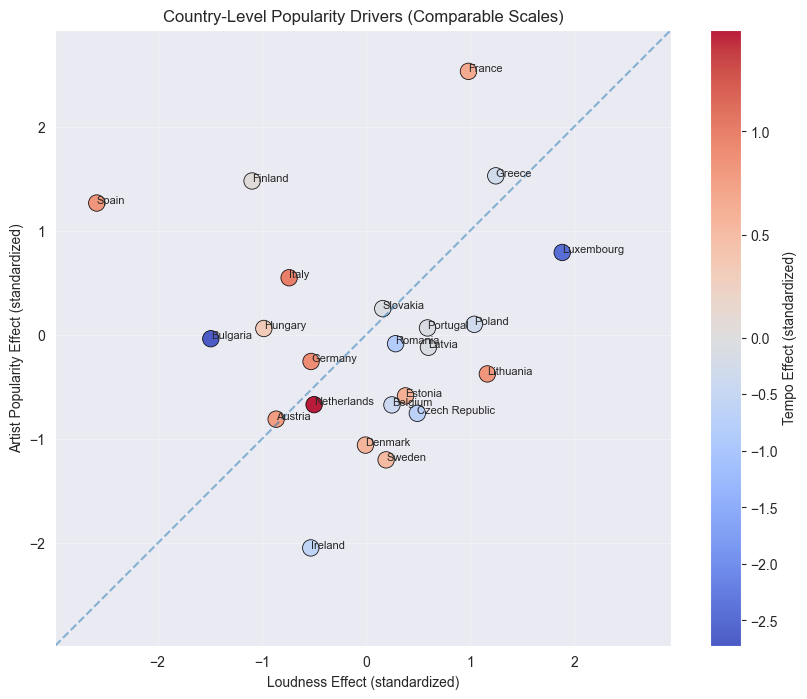

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

df = summary_df.copy()

# Standardize (z-score): now loudness/artist/tempo are comparable
for col in ["loudness_coef", "artist_pop_coef", "tempo_coef"]:
    df[col + "_z"] = (df[col] - df[col].mean()) / df[col].std(ddof=0)

x = df["loudness_coef_z"]
y = df["artist_pop_coef_z"]
c = df["tempo_coef_z"]

# Same range for X and Y (in standardized units)
pad = 0.4
axis_min = min(x.min(), y.min()) - pad
axis_max = max(x.max(), y.max()) + pad

# Color scale centered at 0 (standardized tempo)
norm = TwoSlopeNorm(vmin=c.min(), vcenter=0, vmax=c.max())

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    x, y,
    c=c,
    cmap="coolwarm",
    norm=norm,
    s=140,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9
)
plt.colorbar(sc, label="Tempo Effect (standardized)")

# Equal axes (now it won't squash the data)
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)
plt.gca().set_aspect("equal", adjustable="box")

# Reference diagonal: above = artist > loudness (in standardized effect)
plt.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--", alpha=0.5)

# Labels
for _, row in df.iterrows():
    plt.text(row["loudness_coef_z"], row["artist_pop_coef_z"], row["country"], fontsize=8)

plt.xlabel("Loudness Effect (standardized)")
plt.ylabel("Artist Popularity Effect (standardized)")
plt.title("Country-Level Popularity Drivers (Comparable Scales)")
plt.grid(True, alpha=0.3)
plt.show()

## Summary

✅ Artist popularity is the dominant driver of track success across most European markets

✅ Loudness has a meaningful but secondary role. Some markets (e.g., Luxembourg, Greece) are more production-sensitive, while others are clearly artist-driven

✅ Tempo shows a consistently weak and negative effect. Faster songs do not systematically increase popularity and, in several markets, slightly reduce it.

✅ France and Spain stand out as strongly artist-driven markets, while Luxembourg shows unusually high sensitivity to loudness. Ireland appears less influenced by artist popularity compared to other countries.

✅ Overall, who performs the song matters more than how fast it is, and slightly more than how loud it is, confirming the central role of artist influence in streaming-era popularity.